In [1]:
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os

os.makedirs("data/raw", exist_ok=True)

koneksi dan load data dari mongodb

In [3]:
from dotenv import load_dotenv

load_dotenv(r"C:\skripsi\docker\.env")

MONGO_URI = os.getenv("MONGODB_CONNECTION_STRING")
DB_NAME   = os.getenv("MONGODB_DATABASE")
COL_NAME  = os.getenv("MONGODB_COLLECTION")

client = MongoClient(MONGO_URI)
db     = client[DB_NAME]
cowrie = db[COL_NAME]

# total = cowrie.count_documents({})
# print(f"total dokumen di koleksi cowrie: {total:,}")

data = list(cowrie.find().limit(100000))
df   = pd.DataFrame(data)
print(f"data yang diambil: {len(df):,} baris")

data yang diambil: 100,000 baris


statistik dasar

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 39 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   _id              100000 non-null  object        
 1   eventid          100000 non-null  object        
 2   src_ip           100000 non-null  object        
 3   src_port         15047 non-null   float64       
 4   dst_ip           15118 non-null   object        
 5   dst_port         15118 non-null   float64       
 6   session          100000 non-null  object        
 7   protocol         14976 non-null   object        
 8   message          100000 non-null  object        
 9   sensor           100000 non-null  object        
 10  timestamp        100000 non-null  object        
 11  time             100000 non-null  datetime64[ns]
 12  duration         20349 non-null   float64       
 13  username         18175 non-null   object        
 14  password         1813

In [5]:
df.head()

,_id,eventid,src_ip,src_port,dst_ip,dst_port,session,protocol,message,sensor,...,input,data,id,fingerprint,key,type,filename,outfile,url,destfile
0,66012b322724f42437b00e2a,cowrie.session.connect,::ffff:112.11.222.190,54799.0,::ffff:172.17.0.2,23.0,353d55b301f8,telnet,New connection: ::ffff:112.11.222.190:54799 (:...,5d460e28b540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,66012b322724f42437b00e2b,cowrie.session.closed,::ffff:112.11.222.190,NaN,NaN,NaN,353d55b301f8,NaN,Connection lost after 39 seconds,5d460e28b540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,66012b322724f42437b00e2c,cowrie.session.connect,::ffff:149.50.103.48,47838.0,::ffff:172.17.0.2,23.0,d2092f5e9efe,telnet,New connection: ::ffff:149.50.103.48:47838 (::...,5d460e28b540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,66012b322724f42437b00e2d,cowrie.login.success,::ffff:149.50.103.48,NaN,NaN,NaN,d2092f5e9efe,NaN,login attempt [root/admin] succeeded,5d460e28b540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,66012b322724f42437b00e2e,cowrie.session.params,::ffff:149.50.103.48,NaN,NaN,NaN,d2092f5e9efe,NaN,[],5d460e28b540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("\n--- statistik numerik ---")
df.describe()


--- statistik numerik ---


,src_port,dst_port,time,duration,size,id
count,15047.000000,15118.000000,100000,20349.000000,5374.000000,71.0
mean,47015.255466,31.273250,2024-04-11 05:52:06.015997696,7.260873,286.270190,0.0
min,0.000000,22.000000,2024-03-25 07:42:45.710000,0.000311,0.000000,0.0
25%,39418.000000,22.000000,2024-04-14 18:40:27.312749824,0.615674,0.000000,0.0
50%,47926.000000,22.000000,2024-04-15 09:58:30.288000,1.749895,32.000000,0.0
75%,56378.000000,22.000000,2024-04-15 23:12:41.244250112,3.487797,32.000000,0.0
max,65516.000000,7227.000000,2024-04-16 09:59:21.238000,183.738870,5631.000000,0.0
std,11642.767213,248.596099,NaN,20.367839,712.536951,0.0


analisis missing value

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "jumlah missing": missing,
    "persentase (%)": missing_pct
}).sort_values("persentase (%)", ascending=False)

print(missing_df[missing_df["jumlah missing"] > 0])

                 jumlah missing  persentase (%)
filename                  99998          100.00
url                       99982           99.98
fingerprint               99958           99.96
type                      99958           99.96
key                       99958           99.96
data                      99929           99.93
id                        99929           99.93
destfile                  98064           98.06
outfile                   98060           98.06
size                      94626           94.63
ttylog                    94626           94.63
arch                      94609           94.61
duplicate                 92690           92.69
shasum                    92686           92.69
keyAlgs                   87428           87.43
langCS                    87428           87.43
compCS                    87428           87.43
macCS                     87428           87.43
encCS                     87428           87.43
kexAlgs                   87428         

visualisasi missing values

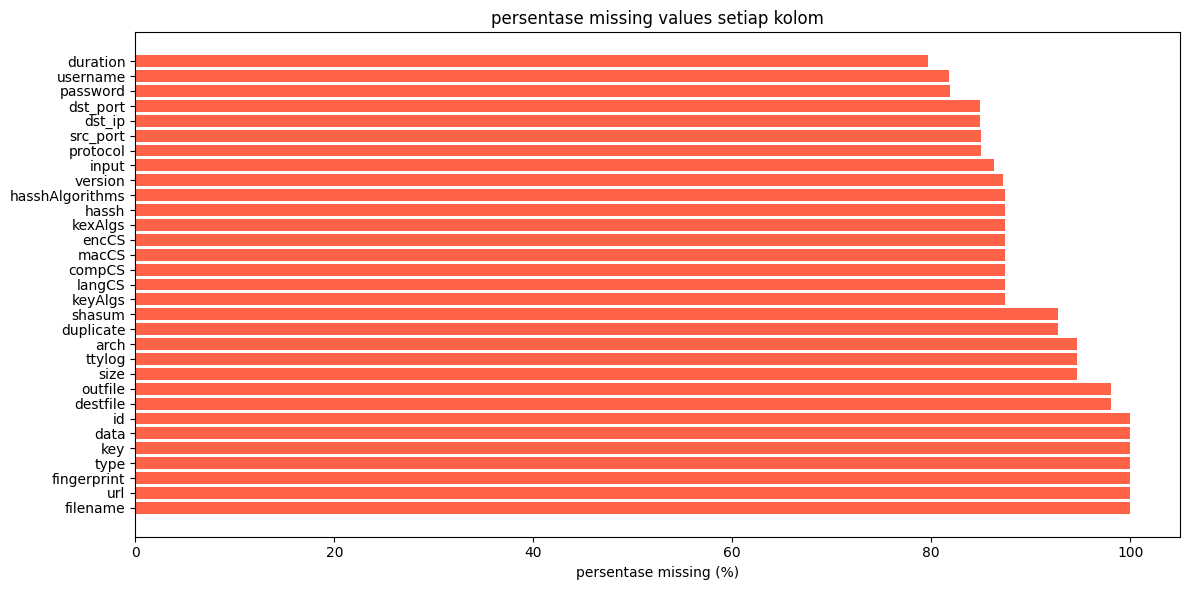

In [8]:
plt.figure(figsize=(12, 6))
missing_plot = missing_df[missing_df["jumlah missing"] > 0]
plt.barh(missing_plot.index, missing_plot["persentase (%)"], color="tomato")
plt.xlabel("persentase missing (%)")
plt.title("persentase missing values setiap kolom")
plt.tight_layout()
plt.savefig("data/raw/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

analisis eventid

In [9]:
eventid_counts = df["eventid"].value_counts()
eventid_tabel = eventid_counts.reset_index()
eventid_tabel.columns = ['eventid', 'jumlah']
print(f"total jenis eventid: {len(eventid_tabel)}\n")
eventid_tabel

total jenis eventid: 17



,eventid,jumlah
0,cowrie.session.connect,14976
1,cowrie.session.closed,14975
2,cowrie.login.failed,13224
3,cowrie.client.version,12766
4,cowrie.client.kex,12572
5,cowrie.command.input,9567
6,cowrie.session.params,5391
7,cowrie.log.closed,5374
8,cowrie.login.success,4909
9,cowrie.command.failed,3637


visualisasi distribusi eventid

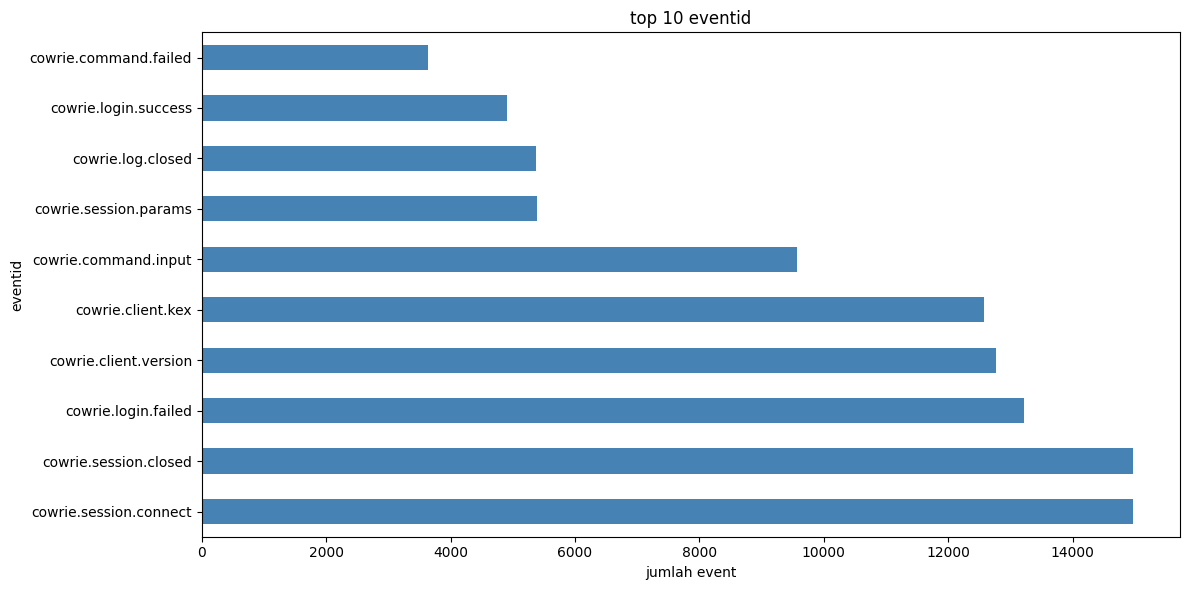

In [10]:
eventid_counts = df["eventid"].value_counts()
plt.figure(figsize=(12, 6))
eventid_counts.head(10).plot(kind="barh", color="steelblue")
plt.xlabel("jumlah event")
plt.title("top 10 eventid")
plt.tight_layout()
plt.savefig("data/raw/distribusi_eventid.png", dpi=150, bbox_inches="tight")
plt.show()

analisis serangan login

In [11]:
login_events = df[df["eventid"].str.contains("login", case=False, na=False)]
print(f"total event login: {len(login_events):,}\n")

print("--- distribusi event login ---")
login_tabel = login_events["eventid"].value_counts().reset_index()
login_tabel.columns = ['eventid', 'jumlah']
display(login_tabel)

print("\n--- top 10 username yang dicoba ---")
username_tabel = login_events["username"].value_counts().reset_index()
username_tabel.columns = ['username', 'jumlah percobaan']
display(username_tabel.head(10))

print("\n--- top 10 password yang dicoba ---")
password_tabel = login_events["password"].value_counts().reset_index()
password_tabel.columns = ['password', 'jumlah percobaan']
display(password_tabel.head(10))

total event login: 18,133

--- distribusi event login ---


,eventid,jumlah
0,cowrie.login.failed,13224
1,cowrie.login.success,4909



--- top 10 username yang dicoba ---


,username,jumlah percobaan
0,root,5134
1,admin,2829
2,345gs5662d34,1868
3,ubnt,553
4,default,400
5,pi,392
6,user,223
7,super,182
8,telnet,172
9,ubuntu,171



--- top 10 password yang dicoba ---


,password,jumlah percobaan
0,345gs5662d34,1868
1,3245gs5662d34,1862
2,123456,1729
3,,467
4,admin,385
5,1234,342
6,password,320
7,123,319
8,root,280
9,12345,184


analisis ip sumber

In [12]:
srcip_counts = df["src_ip"].value_counts()
print(srcip_counts)
print(f"\ntotal jenis src_ip: {len(srcip_counts)}")

src_ip
170.64.233.57            2568
116.110.83.250           1661
61.56.191.90              825
::ffff:103.147.119.30     803
43.153.80.192             786
                         ... 
::ffff:205.210.31.168       2
::ffff:177.86.79.92         2
::ffff:188.113.175.86       2
::ffff:179.58.147.250       2
::ffff:112.218.69.195       2
Name: count, Length: 1582, dtype: int64

total jenis src_ip: 1582


In [13]:
print("--- top 10 ip penyerang ---")
top_ip = df["src_ip"].value_counts().head(10)
top_ip_tabel = top_ip.reset_index()
top_ip_tabel.columns = ['ip address', 'jumlah serangan']
top_ip_tabel

--- top 10 ip penyerang ---


,ip address,jumlah serangan
0,170.64.233.57,2568
1,116.110.83.250,1661
2,61.56.191.90,825
3,::ffff:103.147.119.30,803
4,43.153.80.192,786
5,103.97.247.139,528
6,143.110.217.212,521
7,116.98.172.187,504
8,43.153.76.99,492
9,43.128.72.250,492


visualisasi top 20 ip sumber

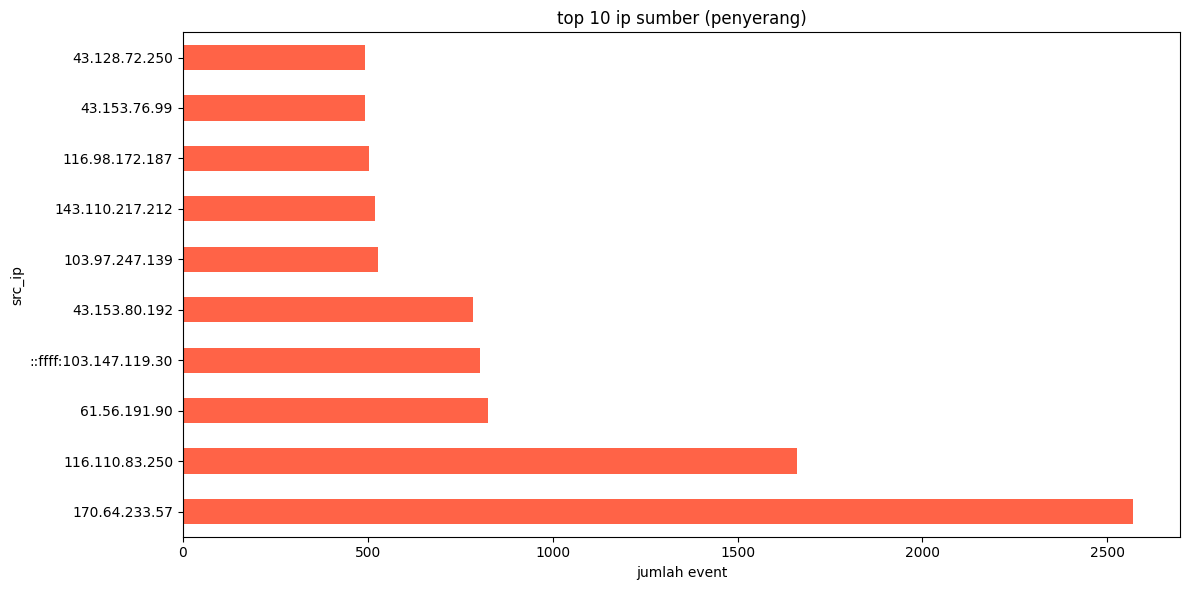

In [14]:
plt.figure(figsize=(12, 6))
top_ip.plot(kind="barh", color="tomato")
plt.xlabel("jumlah event")
plt.title("top 10 ip sumber (penyerang)")
plt.tight_layout()
plt.savefig("data/raw/top_ip_penyerang.png", dpi=150, bbox_inches="tight")
plt.show()

analisis distribusi port

In [15]:
print("--- destination port ---")
dst_port_counts = df["dst_port"].value_counts()
dst_port_tabel = dst_port_counts.reset_index()
dst_port_tabel.columns = ['destination port', 'jumlah percobaan']
display(dst_port_tabel)

print("\n--- top 10 source port ---")
src_port_counts = df["src_port"].value_counts()
src_port_tabel = src_port_counts.reset_index()
src_port_tabel.columns = ['source port', 'jumlah percobaan']
display(src_port_tabel.head(10))

--- destination port ---


,destination port,jumlah percobaan
0,22.0,13117
1,23.0,1859
2,80.0,120
3,7227.0,18
4,443.0,4



--- top 10 source port ---


,source port,jumlah percobaan
0,0.0,69
1,61000.0,21
2,64001.0,9
3,10000.0,6
4,36168.0,6
5,40226.0,5
6,46912.0,5
7,60118.0,5
8,60816.0,5
9,52066.0,5


visualisasi distribusi port

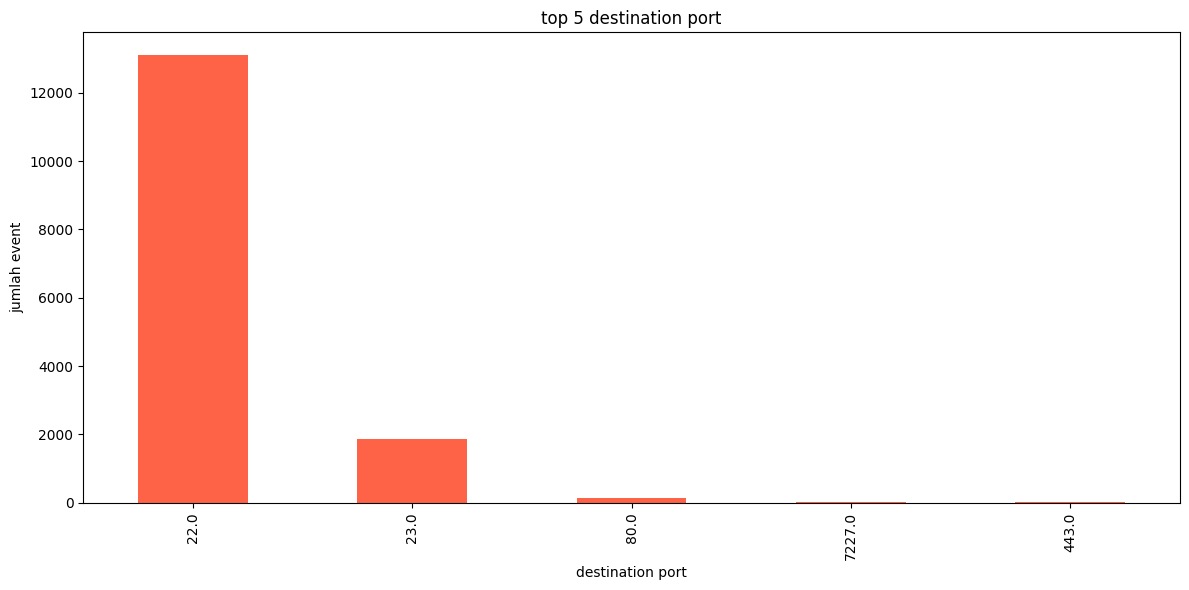

In [16]:
plt.figure(figsize=(12, 6))
top_port = df["dst_port"].value_counts()
top_port.plot(kind="bar", color="tomato")
plt.xlabel("destination port")
plt.ylabel("jumlah event")
plt.title("top 5 destination port")
plt.tight_layout()
plt.savefig("data/raw/distribusi_dst_port.png", dpi=150, bbox_inches="tight")
plt.show()

analisis waktu serangan

In [17]:
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["hour"]  = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month
df["date"]  = df["timestamp"].dt.date

print("--- distribusi serangan setiap jam ---")
print(df["hour"].value_counts().sort_index())

--- distribusi serangan setiap jam ---
hour
0     6329
1     1297
2     6369
3     3696
4     3007
5     1868
6     7420
7     1560
8     3589
9     9562
10    7889
11    2094
12    2952
13    1794
14    1481
15    1997
16    3102
17    2418
18    2966
19    5082
20    1253
21    6217
22    7400
23    8658
Name: count, dtype: int64


visualisasi setiap jam

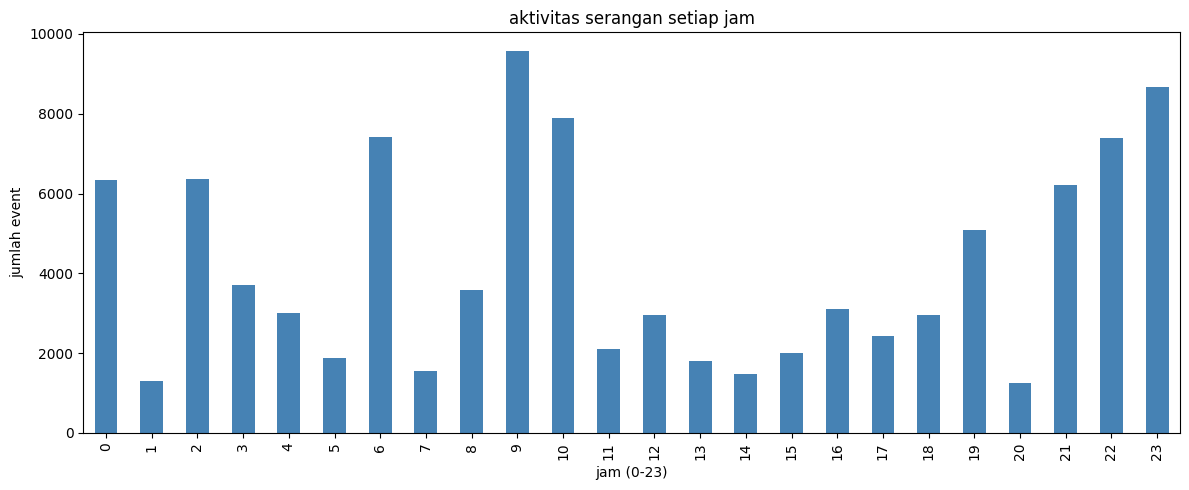

In [18]:
plt.figure(figsize=(12, 5))
df["hour"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.xlabel("jam (0-23)")
plt.ylabel("jumlah event")
plt.title("aktivitas serangan setiap jam")
plt.tight_layout()
plt.savefig("data/raw/distribusi_jam.png", dpi=150, bbox_inches="tight")
plt.show()

visualisasi tren harian

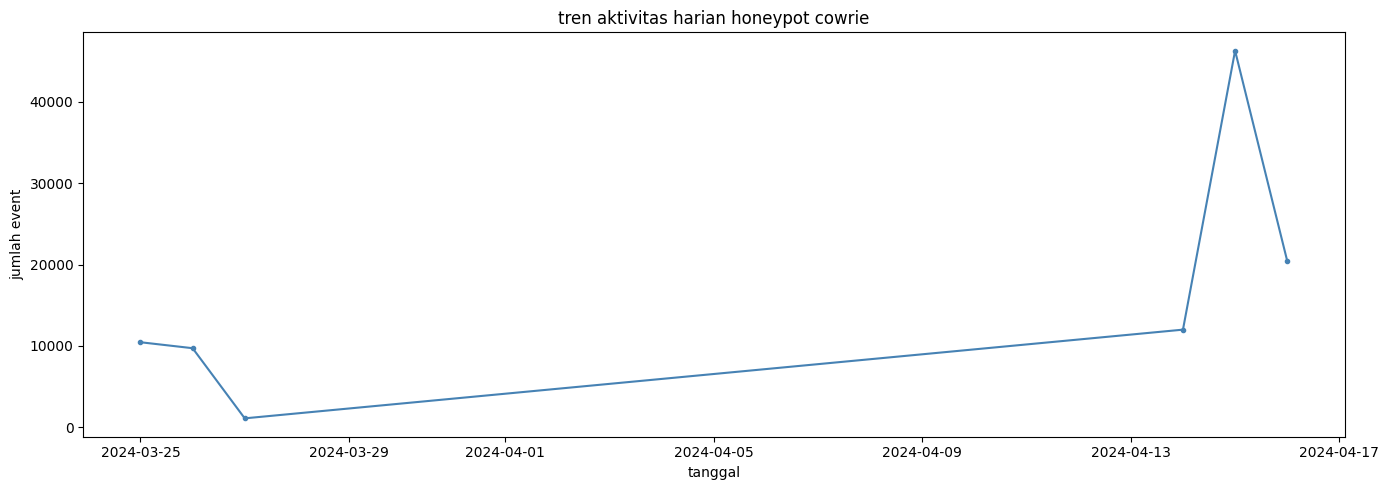

In [19]:
daily_trend = df.groupby("date").size()
plt.figure(figsize=(14, 5))
daily_trend.plot(kind="line", color="steelblue", marker="o", markersize=3)
plt.xlabel("tanggal")
plt.ylabel("jumlah event")
plt.title("tren aktivitas harian honeypot cowrie")
plt.tight_layout()
plt.savefig("data/raw/tren_harian.png", dpi=150, bbox_inches="tight")
plt.show()

analisis durasi sesi

In [20]:
dur_valid = df["duration"].dropna()
dur_valid_tabel = dur_valid.reset_index()
dur_valid_tabel.columns = ['Statistik', 'Nilai']
print(f"jumlah data dengan duration: {len(dur_valid):,}")
dur_valid_tabel.describe()

jumlah data dengan duration: 20,349


,Statistik,Nilai
count,20349.000000,20349.000000
mean,52375.447786,7.260873
std,27938.720657,20.367839
min,1.000000,0.000311
25%,29251.000000,0.615674
50%,53214.000000,1.749895
75%,76188.000000,3.487797
max,99990.000000,183.738870


simpan ringkasan eda

In [21]:
ringkasan = {
    "total_data": len(df),
    "total_kolom": len(df.columns),
    "total_eventid_unik": df["eventid"].nunique(),
    "total_ip_unik": df["src_ip"].nunique(),
    "eventid_terbanyak": df["eventid"].value_counts().index[0],
    "ip_terbanyak": df["src_ip"].value_counts().index[0],
    "rata_rata_durasi": round(df["duration"].mean(), 4),
    "pct_missing_src_port": round(df["src_port"].isnull().mean() * 100, 2),
    "pct_missing_duration": round(df["duration"].isnull().mean() * 100, 2),
}

import json
with open("data/raw/ringkasan_eda.json", "w") as f:
    json.dump(ringkasan, f, indent=2)
print(ringkasan)

{'total_data': 100000, 'total_kolom': 42, 'total_eventid_unik': 17, 'total_ip_unik': 1582, 'eventid_terbanyak': 'cowrie.session.connect', 'ip_terbanyak': '170.64.233.57', 'rata_rata_durasi': 7.2609, 'pct_missing_src_port': 84.95, 'pct_missing_duration': 79.65}


simpan data mentah ke csv

In [22]:
df.to_csv("data/raw/data_raw.csv", index=False)
print(f"total baris: {len(df):,} | total kolom: {len(df.columns)}")
print(f"kolom yang tersimpan: {list(df.columns)}")

total baris: 100,000 | total kolom: 42
kolom yang tersimpan: ['_id', 'eventid', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'session', 'protocol', 'message', 'sensor', 'timestamp', 'time', 'duration', 'username', 'password', 'arch', 'version', 'hassh', 'hasshAlgorithms', 'kexAlgs', 'keyAlgs', 'encCS', 'macCS', 'compCS', 'langCS', 'ttylog', 'size', 'shasum', 'duplicate', 'input', 'data', 'id', 'fingerprint', 'key', 'type', 'filename', 'outfile', 'url', 'destfile', 'hour', 'month', 'date']
